# RAG Pipeline for Scientific Papers
## Notebook 01 — PDF Extraction: Text & Images

**Repository:** `rag-paper-pipeline/notebooks/01_extraction.ipynb`

Extracts text (page-by-page) and figures (embedded rasters + vector-rendered pages) from a scientific paper PDF.  
Output feeds directly into `02_figure_description.ipynb`.

```
rag-paper-pipeline/
 ├── notebooks/          ← you are here
 │    └── 01_extraction.ipynb
 ├── data/papers/        ← place your PDF here
 └── output/             ← generated output lands here
      ├── text/
      └── images/
           ├── embedded/
           └── rendered/
```

## 0. Imports & Configuration

In [5]:
import fitz          # PyMuPDF
import pdfplumber
import os
import json
import re
from pathlib import Path
from PIL import Image
import io

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook lives in notebooks/ → root is one level up
ROOT_DIR   = Path("__file__").resolve().parent.parent if "__file__" in dir() else Path.cwd().parent

# Fallback: if ROOT_DIR doesn't look right, set it manually
# ROOT_DIR = Path("/Users/alexandrosangelis/VS_CODE/rag-paper-pipeline")

DATA_DIR   = ROOT_DIR / "data" / "papers"
OUTPUT_DIR = ROOT_DIR / "output"

# ── Select your paper ─────────────────────────────────────────────────────────
PAPER_NAME = "test1.pdf"          # ← change to your PDF filename
PDF_PATH   = DATA_DIR / PAPER_NAME

# ── Image extraction settings ─────────────────────────────────────────────────
MIN_IMAGE_SIZE = 100    # pixels — ignore tiny icons/bullets
RENDER_DPI     = 150    # DPI for full-page renders (150 = good quality)
RENDER_PAGES   = True   # set False if you only want embedded raster images

# ── Output subdirectories ─────────────────────────────────────────────────────
TEXT_DIR            = OUTPUT_DIR / "text"
IMAGES_EMBEDDED_DIR = OUTPUT_DIR / "images" / "embedded"
IMAGES_RENDERED_DIR = OUTPUT_DIR / "images" / "rendered"
METADATA_PATH       = OUTPUT_DIR / "metadata.json"

for d in [TEXT_DIR, IMAGES_EMBEDDED_DIR, IMAGES_RENDERED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"ROOT    : {ROOT_DIR}")
print(f"PDF     : {PDF_PATH}")
print(f"PDF exists: {PDF_PATH.exists()}")
print()
print("Output directories:")
for d in [TEXT_DIR, IMAGES_EMBEDDED_DIR, IMAGES_RENDERED_DIR]:
    print(f"  {d}")

ROOT    : /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline
PDF     : /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline/data/papers/test1.pdf
PDF exists: True

Output directories:
  /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline/output/text
  /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline/output/images/embedded
  /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline/output/images/rendered


> **Note:** If `PDF exists: False`, either place your PDF in `data/papers/` or update `PAPER_NAME` above.

## 1. PDF Inspection
Quick diagnostic — page count, embedded image count, metadata.

In [6]:
def inspect_pdf(pdf_path: Path) -> dict:
    """Run a quick diagnostic on the PDF."""
    doc = fitz.open(str(pdf_path))
    info = {
        "path"              : str(pdf_path),
        "page_count"        : len(doc),
        "metadata"          : doc.metadata,
        "total_images"      : 0,
        "pages_with_images" : [],
    }
    for page in doc:
        imgs = page.get_images()
        if imgs:
            info["total_images"] += len(imgs)
            info["pages_with_images"].append(page.number + 1)  # 1-indexed
    doc.close()
    return info


info = inspect_pdf(PDF_PATH)

print(f"📄 File         : {info['path']}")
print(f"📑 Pages        : {info['page_count']}")
print(f"🖼️  Embedded imgs : {info['total_images']}")
print(f"   on pages    : {info['pages_with_images']}")
print(f"\nMetadata:")
for k, v in info['metadata'].items():
    if v:
        print(f"  {k}: {v}")

📄 File         : /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline/data/papers/test1.pdf
📑 Pages        : 13
🖼️  Embedded imgs : 7
   on pages    : [2, 3, 6, 7, 9, 10, 11]

Metadata:
  format: PDF 1.3
  title: IJN-26592-endocytosis-and-exocytosis-of-nanoparticles-in-mammalian-cel
  author: Park
  subject: Endocytosis and exocytosis of nanoparticles in mammalian cells
  creator: Adobe InDesign CS3 (5.0.4)
  producer: macOS Έκδοση 14.1.1 (Δομή 23B81) Quartz PDFContext
  creationDate: D:20231206123250Z00'00'
  modDate: D:20231206123250Z00'00'


## 2. Text Extraction
Uses `pdfplumber` (layout-aware, handles multi-column papers better than pypdf).  
Each page → separate `.txt` file in `output/text/`.

In [17]:
import pdfplumber
import re
from pathlib import Path


def clean_text(raw: str) -> str:
    if not raw:
        return ""
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', raw)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def find_column_split(page) -> float | None:
    """
    Find the gutter between columns by looking for a horizontal gap
    in word x0 positions. Returns split x-coordinate or None if single column.
    """
    words = page.extract_words()
    if not words:
        return None

    # Get all x0 positions sorted
    x0s = sorted(set(round(w['x0']) for w in words))

    # Find the largest gap in x0 positions — that's the gutter
    max_gap  = 0
    split_at = None
    for i in range(1, len(x0s)):
        gap = x0s[i] - x0s[i - 1]
        if gap > max_gap:
            max_gap  = gap
            split_at = (x0s[i - 1] + x0s[i]) / 2   # midpoint of gap

    # Only treat as two-column if the gap is meaningful (>8 pts)
    # AND the split is not too close to the margins
    left_margin  = page.width * 0.10
    right_margin = page.width * 0.90
    if max_gap > 8 and left_margin < split_at < right_margin:
        return split_at
    return None


def extract_page_text(page) -> tuple[str, bool, float | None]:
    """
    Extract text handling two-column layout automatically.
    Returns (text, is_two_col, split_x).
    """
    split_x = find_column_split(page)

    if split_x is not None:
        left_bbox  = (0,          0, split_x,     page.height)
        right_bbox = (split_x,    0, page.width,  page.height)

        left_text  = page.crop(left_bbox).extract_text(
            x_tolerance=2, y_tolerance=3) or ""
        right_text = page.crop(right_bbox).extract_text(
            x_tolerance=2, y_tolerance=3) or ""

        combined = clean_text(left_text) + "\n\n" + clean_text(right_text)
        return combined, True, split_x
    else:
        raw  = page.extract_text(x_tolerance=2, y_tolerance=3)
        return clean_text(raw or ""), False, None


def extract_text_smart(pdf_path: Path, output_dir: Path) -> list:
    pages = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        total = len(pdf.pages)
        for i, page in enumerate(pdf.pages):
            page_num            = i + 1
            text, two_col, split_x = extract_page_text(page)

            txt_path = output_dir / f"page_{page_num:03d}.txt"
            txt_path.write_text(text, encoding="utf-8")

            pages.append({
                "page"       : page_num,
                "char_count" : len(text),
                "two_column" : two_col,
                "split_x"    : split_x,
                "text_path"  : str(txt_path),
                "text"       : text,
            })
            layout = f"2-col (split@{split_x:.0f})" if two_col else "1-col"
            print(f"  Page {page_num:3d}/{total} [{layout}] — {len(text):,} chars")

    return pages


# ── Run ───────────────────────────────────────────────────────────────────────
print("Extracting text (auto column detection)...")
pages = extract_text_smart(PDF_PATH, TEXT_DIR)
print(f"\n✅ {len(pages)} pages — {sum(p['char_count'] for p in pages):,} total chars")
print(f"   Two-column pages: {[p['page'] for p in pages if p['two_column']]}")

Extracting text (auto column detection)...
  Page   1/13 [2-col (split@204)] — 4,074 chars
  Page   2/13 [2-col (split@519)] — 3,395 chars
  Page   3/13 [2-col (split@312)] — 4,255 chars
  Page   4/13 [2-col (split@294)] — 5,330 chars
  Page   5/13 [2-col (split@304)] — 4,300 chars
  Page   6/13 [2-col (split@299)] — 2,721 chars
  Page   7/13 [2-col (split@317)] — 3,111 chars
  Page   8/13 [1-col] — 4,417 chars
  Page   9/13 [1-col] — 3,475 chars
  Page  10/13 [2-col (split@516)] — 2,270 chars
  Page  11/13 [2-col (split@312)] — 3,901 chars
  Page  12/13 [2-col (split@294)] — 8,014 chars
  Page  13/13 [2-col (split@306)] — 1,030 chars

✅ 13 pages — 50,293 total chars
   Two-column pages: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13]


In [18]:
# import pdfplumber
 
# # ── Run this diagnostic cell first to find the real column boundary ───────────
# with pdfplumber.open(str(PDF_PATH)) as pdf:
#     page  = pdf.pages[0]   # check page 1
#     words = page.extract_words()
 
#     print(f"Page width : {page.width:.1f} pts")
#     print(f"Page height: {page.height:.1f} pts")
#     print(f"Total words: {len(words)}")
#     print()
 
#     # Show x0 (left edge) of every word — look for the GAP between columns
#     x0_values = sorted(set(round(w['x0']) for w in words))
#     print("Unique x0 positions (left edges of words):")
#     print(x0_values)
#     print()
 
#     # Find the gap: a range of x values with NO words starting there
#     # That gap is the gutter between columns
#     page_mid = page.width / 2
#     nearby = [x for x in x0_values if page_mid - 80 < x < page_mid + 80]
#     print(f"X positions near midpoint ({page_mid:.0f} ± 80 pts):")
#     print(nearby)
#     print()
 
#     # Show words straddling the midpoint
#     print("Words near the middle of the page (x0 between 200-400):")
#     for w in sorted(words, key=lambda w: w['x0']):
#         if 200 < w['x0'] < 400:
#             print(f"  x0={w['x0']:6.1f}  x1={w['x1']:6.1f}  '{w['text']}'")
 

In [19]:
# def clean_text(raw: str) -> str:
#     """Basic cleanup: fix hyphenated line breaks, collapse blank lines."""
#     if not raw:
#         return ""
#     # Re-join hyphenated words split across lines (common in justified text)
#     text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', raw)
#     # Collapse multiple blank lines into one
#     text = re.sub(r'\n{3,}', '\n\n', text)
#     return text.strip()


# def extract_text(pdf_path: Path, output_dir: Path) -> list:
#     """Extract text page-by-page. Returns list of page records."""
#     pages = []
#     with pdfplumber.open(str(pdf_path)) as pdf:
#         total = len(pdf.pages)
#         for i, page in enumerate(pdf.pages):
#             page_num = i + 1
#             raw  = page.extract_text(x_tolerance=2, y_tolerance=3)
#             text = clean_text(raw or "")

#             txt_path = output_dir / f"page_{page_num:03d}.txt"
#             txt_path.write_text(text, encoding="utf-8")

#             pages.append({
#                 "page"       : page_num,
#                 "char_count" : len(text),
#                 "text_path"  : str(txt_path),
#                 "text"       : text,   # kept in memory for chunking step
#             })
#             print(f"  Page {page_num:3d}/{total} — {len(text):,} chars")
#     return pages


# print("Extracting text...")
# pages = extract_text(PDF_PATH, TEXT_DIR)
# print(f"\n✅ {len(pages)} pages extracted — {sum(p['char_count'] for p in pages):,} total chars")

In [20]:
# ── Quick text preview ────────────────────────────────────────────────────────
PREVIEW_PAGE = 1   # ← change to any page number

rec = pages[PREVIEW_PAGE - 1]
print(f"=== Page {PREVIEW_PAGE} ({rec['char_count']:,} chars) ===")
print(rec['text'][:1500])
if len(rec['text']) > 1500:
    print(f"\n... [{len(rec['text']) - 1500:,} more chars]")

=== Page 1 (4,074 chars) ===
International Journal o
Open Access Full Text Article
Endocytosis an
in mammalian
Nuri Oh1,2
Ji-Ho Park1–3
1Department of Bio and Brain
Engineering, 2Institute for Optical
Science and Technology, 3Institute for
the NanoCentury, Korea Advanced
Institute of Science and Technology
(KAIST), Daejeon, Republic of Korea
Correspondence: Ji-Ho Park
Department of Bio and Brain
Engineering, Institute for Optical Science
and Technology, Institute for the
NanoCentury, Korea Advanced Institute
of Science and Technology (KAIST),
Daejeon, Republic of Korea
Tel +82 42 350 4330
Email jihopark@kaist.ac.kr
submit your manuscript | www.dovepress.com
Dovepress
http://dx.doi.org/10.2147/IJN.S26592

of Nanomedicine Dovepress
open access to scientific and medical research
R E V I E W
nd exocytosis of nanoparticles
n cells
Abstract: Engineered nanoparticles that can be injected into the human body hold tremendous
potential to detect and treat complex diseases. Understanding of the e

In [21]:
# Preview a body page — should be clean two-column text
PREVIEW_PAGE = 4   # a text-heavy page with no figures

rec = pages[PREVIEW_PAGE - 1]
print(f"=== Page {PREVIEW_PAGE} ({rec['char_count']:,} chars) | split@{rec['split_x']:.0f} ===")
print(rec['text'][:2000])

=== Page 4 (5,330 chars) | split@294 ===
Oh and Park
endocytosis indicates receptor-mediated endocytosis. Many
types of cells use the clathrin- and caveolae-mediated
endocytosis pathways to internalize nanoscale materials,
including viruses and nanoparticles.19–21 These endocytosis
pathways are the most important pathways for the internalization of nanoparticles into cells because the nanoparticles
are directly coated with the plasma proteins when exposed
to physiological solutions. The phagocytosis pathway is
used when phagocytic cells internalize foreign materials
with sizes larger than 0.5 μm.16 The phagocytosis pathway
is actin-dependent and restricted to professional phagocytes,
such as macrophages, dendritic cells, and neutrophils. The
macropinocytosis pathway is a non-specific process to
internalize fluids and particles together into the cell, whereas
the pinocytosis pathway absorbs biological fluids from the
external environment of a cell.22 These pathways are very
important to

## 3. Image Extraction

| Strategy | What it catches | Tool |
|---|---|---|
| **Embedded raster** | JPEGs/PNGs in the PDF object tree | PyMuPDF `get_images()` |
| **Full-page render** | Vector plots (matplotlib, R, LaTeX) | PyMuPDF `get_pixmap()` at 150 DPI |

> Vector plots drawn as PDF operators are **invisible** to `get_images()` — page rasterisation captures everything.

In [22]:
def extract_embedded_images(pdf_path: Path, output_dir: Path, min_size: int = 100) -> list:
    """
    Extract raster images from the PDF object tree.
    Skips tiny images (icons, bullets). Deduplicates by xref.
    """
    doc     = fitz.open(str(pdf_path))
    records = []
    seen    = set()

    for page in doc:
        page_num = page.number + 1
        for img in page.get_images(full=True):
            xref = img[0]
            if xref in seen:
                continue
            seen.add(xref)

            try:
                pix = fitz.Pixmap(doc, xref)
                if pix.n - pix.alpha > 3:   # convert CMYK → RGB
                    pix = fitz.Pixmap(fitz.csRGB, pix)
            except Exception as e:
                print(f"  ⚠️  Page {page_num}, xref {xref}: {e}")
                continue

            if pix.width < min_size or pix.height < min_size:
                continue

            fname = f"page_{page_num:03d}_img_{xref:04d}.png"
            fpath = output_dir / fname
            pix.save(str(fpath))

            records.append({
                "type"           : "embedded",
                "page"           : page_num,
                "xref"           : xref,
                "width"          : pix.width,
                "height"         : pix.height,
                "path"           : str(fpath),
                "description"    : None,   # filled by notebook 02
                "figure_caption" : None,
            })
            print(f"  Page {page_num:3d} | xref {xref:4d} | {pix.width}×{pix.height}px → {fname}")

    doc.close()
    return records


print("Extracting embedded raster images...")
embedded_images = extract_embedded_images(PDF_PATH, IMAGES_EMBEDDED_DIR, MIN_IMAGE_SIZE)
print(f"\n✅ {len(embedded_images)} embedded images saved")

Extracting embedded raster images...
  Page   2 | xref   37 | 1341×1318px → page_002_img_0037.png
  Page   3 | xref   48 | 1146×1036px → page_003_img_0048.png
  Page   6 | xref  104 | 1750×1884px → page_006_img_0104.png
  Page   7 | xref  127 | 684×1274px → page_007_img_0127.png
  Page   9 | xref  157 | 1572×1402px → page_009_img_0157.png
  Page  10 | xref  171 | 1467×2349px → page_010_img_0171.png
  Page  11 | xref  182 | 1043×1440px → page_011_img_0182.png

✅ 7 embedded images saved


In [23]:
def render_pages(pdf_path: Path, output_dir: Path, dpi: int = 150) -> list:
    """
    Rasterise every page at `dpi` resolution.
    Catches vector plots (matplotlib, R, LaTeX) invisible to get_images().
    """
    doc     = fitz.open(str(pdf_path))
    mat     = fitz.Matrix(dpi / 72, dpi / 72)   # PDF native = 72 dpi
    records = []

    for page in doc:
        page_num = page.number + 1
        pix      = page.get_pixmap(matrix=mat, alpha=False)

        fname = f"page_{page_num:03d}_render.png"
        fpath = output_dir / fname
        pix.save(str(fpath))

        records.append({
            "type"           : "rendered",
            "page"           : page_num,
            "width"          : pix.width,
            "height"         : pix.height,
            "dpi"            : dpi,
            "path"           : str(fpath),
            "description"    : None,   # filled by notebook 02
            "figure_caption" : None,
        })
        print(f"  Page {page_num:3d} | {pix.width}×{pix.height}px → {fname}")

    doc.close()
    return records


if RENDER_PAGES:
    print("Rendering pages (catches vector plots)...")
    rendered_pages = render_pages(PDF_PATH, IMAGES_RENDERED_DIR, dpi=RENDER_DPI)
    print(f"\n✅ {len(rendered_pages)} page renders saved")
else:
    rendered_pages = []
    print("Page rendering skipped (RENDER_PAGES=False).")

Rendering pages (catches vector plots)...
  Page   1 | 1275×1650px → page_001_render.png
  Page   2 | 1275×1650px → page_002_render.png
  Page   3 | 1275×1650px → page_003_render.png
  Page   4 | 1275×1650px → page_004_render.png
  Page   5 | 1275×1650px → page_005_render.png
  Page   6 | 1275×1650px → page_006_render.png
  Page   7 | 1275×1650px → page_007_render.png
  Page   8 | 1275×1650px → page_008_render.png
  Page   9 | 1275×1650px → page_009_render.png
  Page  10 | 1275×1650px → page_010_render.png
  Page  11 | 1275×1650px → page_011_render.png
  Page  12 | 1275×1650px → page_012_render.png
  Page  13 | 1275×1650px → page_013_render.png

✅ 13 page renders saved


## 4. Quick Visual Check

── Embedded raster images (first 4) ──


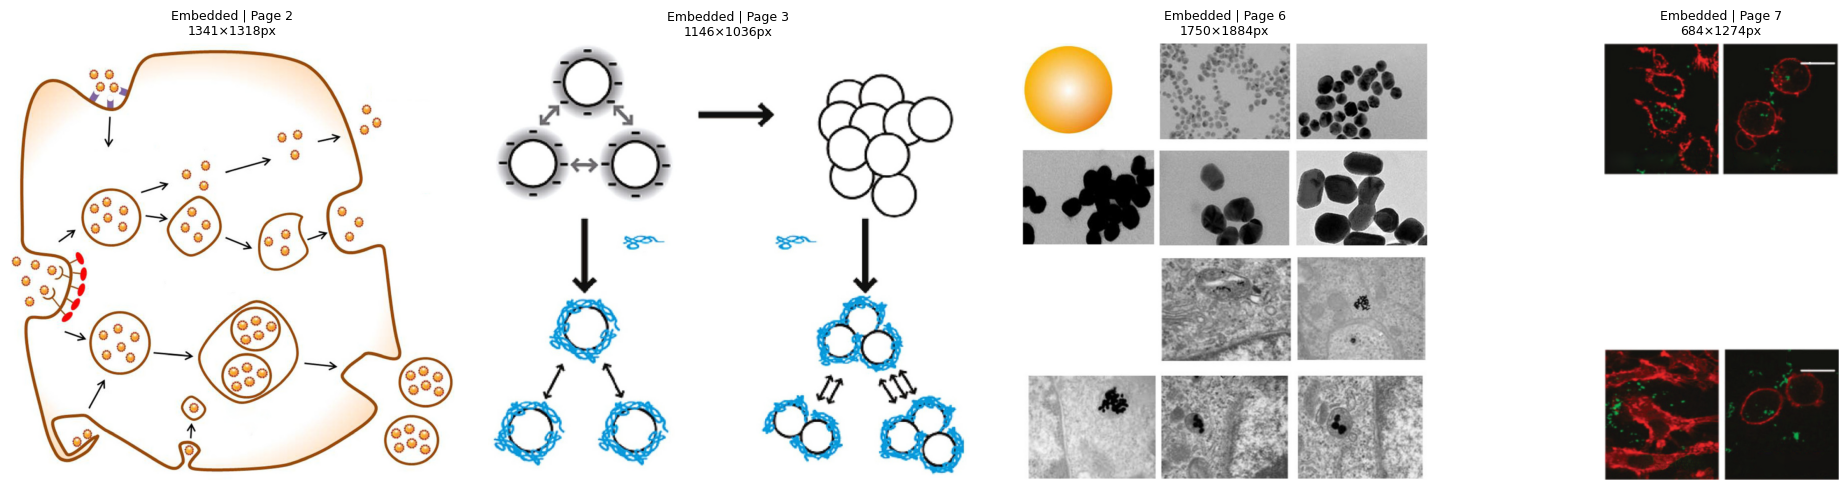

── Full-page renders (first 4) ──


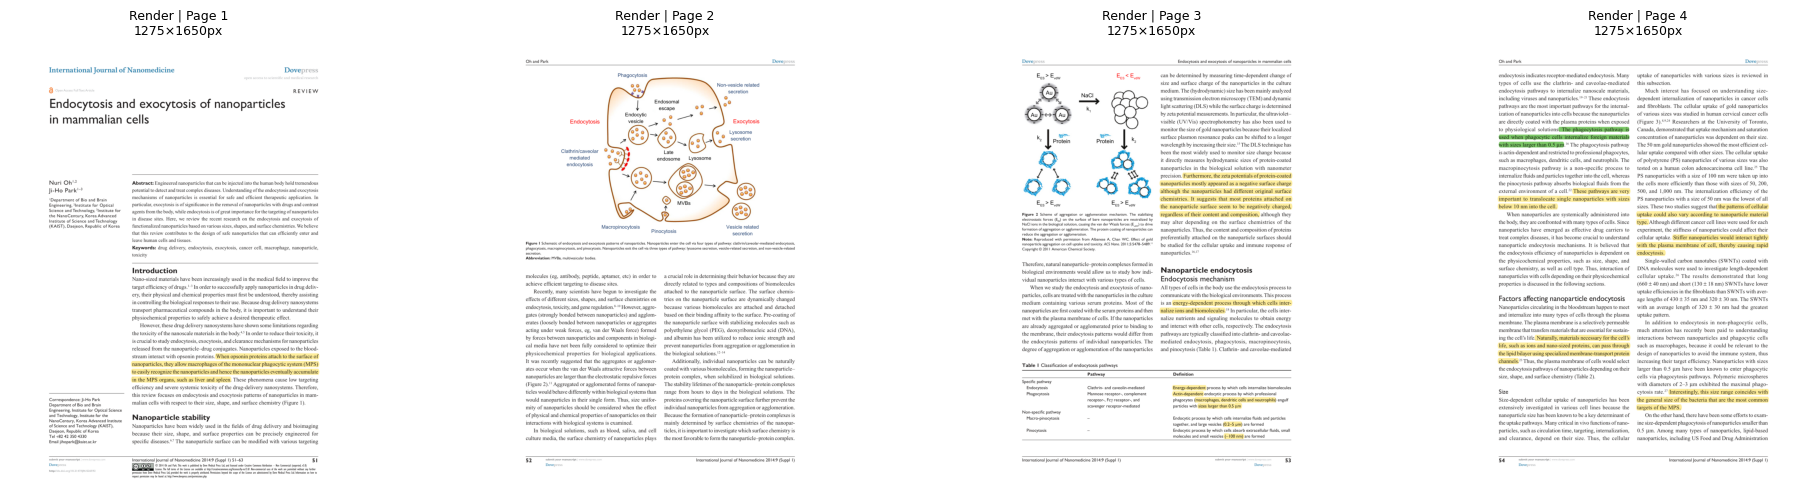

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_images(records: list, max_show: int = 4, title_prefix: str = ""):
    sample = records[:max_show]
    if not sample:
        print("No images to display.")
        return
    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]
    for ax, rec in zip(axes, sample):
        img = mpimg.imread(rec['path'])
        ax.imshow(img)
        ax.set_title(f"{title_prefix}Page {rec['page']}\n{rec['width']}×{rec['height']}px", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


if embedded_images:
    print("── Embedded raster images (first 4) ──")
    show_images(embedded_images, max_show=4, title_prefix="Embedded | ")

if rendered_pages:
    print("── Full-page renders (first 4) ──")
    show_images(rendered_pages, max_show=4, title_prefix="Render | ")

## 5. Save Metadata Index
All records saved to `output/metadata.json` — used by all subsequent notebooks.

In [25]:
metadata = {
    "pdf_path"        : str(PDF_PATH),
    "paper_name"      : PAPER_NAME,
    "page_count"      : info["page_count"],
    "pdf_metadata"    : info["metadata"],
    "text_pages"      : [{k: v for k, v in p.items() if k != "text"} for p in pages],
    "embedded_images" : embedded_images,
    "rendered_pages"  : rendered_pages,
    "summary": {
        "text_pages_extracted"  : len(pages),
        "embedded_images_found" : len(embedded_images),
        "page_renders_saved"    : len(rendered_pages),
    }
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Metadata saved → {METADATA_PATH}")
print()
print("══ Extraction Summary ══════════════════")
for k, v in metadata["summary"].items():
    print(f"  {k:<30}: {v}")
print("════════════════════════════════════════")
print()
print("✅ Ready for notebook 02 — figure description")

Metadata saved → /Users/alexandrosangelis/Documents/VS_CODE/rag-paper-pipeline/output/metadata.json

══ Extraction Summary ══════════════════
  text_pages_extracted          : 13
  embedded_images_found         : 7
  page_renders_saved            : 13
════════════════════════════════════════

✅ Ready for notebook 02 — figure description


## 6. Output Tree

In [26]:
def print_tree(root: Path, max_files: int = 5):
    for dirpath, dirs, files in os.walk(root):
        dirs.sort()
        level  = Path(dirpath).relative_to(root).parts
        indent = "  " * len(level)
        print(f"{indent}📁 {Path(dirpath).name}/")
        sub   = "  " * (len(level) + 1)
        shown = sorted(files)[:max_files]
        for f in shown:
            size = (Path(dirpath) / f).stat().st_size
            print(f"{sub}📄 {f}  ({size/1024:.1f} KB)")
        if len(files) > max_files:
            print(f"{sub}... and {len(files) - max_files} more files")

print_tree(OUTPUT_DIR)

📁 output/
  📄 .gitkeep  (0.0 KB)
  📄 metadata.json  (9.3 KB)
  📁 images/
    📁 embedded/
      📄 page_002_img_0037.png  (1216.1 KB)
      📄 page_003_img_0048.png  (605.7 KB)
      📄 page_006_img_0104.png  (2266.9 KB)
      📄 page_007_img_0127.png  (646.9 KB)
      📄 page_009_img_0157.png  (1634.9 KB)
      ... and 2 more files
    📁 rendered/
      📄 page_001_render.png  (318.1 KB)
      📄 page_002_render.png  (537.8 KB)
      📄 page_003_render.png  (486.9 KB)
      📄 page_004_render.png  (451.5 KB)
      📄 page_005_render.png  (326.2 KB)
      ... and 8 more files
  📁 text/
    📄 page_001.txt  (4.0 KB)
    📄 page_002.txt  (3.3 KB)
    📄 page_003.txt  (4.2 KB)
    📄 page_004.txt  (5.2 KB)
    📄 page_005.txt  (4.2 KB)
    ... and 8 more files


---
## Next → `02_figure_description.ipynb`

| Notebook | Description |
|---|---|
| `02_figure_description.ipynb` | Pass each image to Claude Vision → structured description → saved in metadata |
| `03_chunking_embedding.ipynb` | Chunk text + figure descriptions → embed with `text-embedding-3-small` |
| `04_retrieval_qa.ipynb` | Query → vector search → retrieve chunk + image → Claude generates answer |